##### Imports and definitions

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
from pathlib import Path

_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.config import ANALYSIS_DIR, FIGURES_DIR
from src.palette import celltype_palette
from src.vis import (
    setup_matplotlib_params,
    plot_veres_panel,
    plot_veres_panel_highlight,
    make_label_params,
    prepare_for_scatter,
)

setup_matplotlib_params()


def plot_veres_triptych(
    adata, split_key, donors, label_key, label_order,
    palette, title=None, save=None, dpi=600,
):
    """Three Veres-style UMAP scatters side-by-side with one shared legend."""
    cats = label_order
    lp = make_label_params(cats, palette=palette)

    mm = 25.4
    panel_w = 89 / 2 / mm
    fig_w = panel_w * 3 + 0.6
    fig_h = panel_w * 0.75
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)

    gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.4],
                           wspace=0.05)

    s_black, s_white, s_type = 4, 2, 1.5

    for i, donor in enumerate(donors):
        ad = adata[adata.obs[split_key] == donor].copy()
        X = ad.obsm["X_umap"]
        labels = ad.obs[label_key].astype(str).values
        proj, rgb = prepare_for_scatter(X, labels, lp)

        ax = fig.add_subplot(gs[0, i])
        ax.scatter(proj[:, 0], proj[:, 1], c="k", s=s_black, edgecolor="none", rasterized=True)
        ax.scatter(proj[:, 0], proj[:, 1], c="w", s=s_white, edgecolor="none", rasterized=True)
        ax.scatter(proj[:, 0], proj[:, 1], c=rgb, s=s_type, alpha=0.7, edgecolor="none", rasterized=True)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xlabel(f"{donor} ({ad.n_obs:,})", fontsize=6, fontweight="bold", labelpad=4)
        ax.set_ylabel("")
        ax.set_title("")

    # Shared legend
    ax_leg = fig.add_subplot(gs[0, 3])
    ax_leg.axis("off")
    present = [c for c in cats if c in set(adata.obs[label_key].astype(str))]
    for j, lb in enumerate(present):
        y = 1.0 - j * 0.09
        ax_leg.scatter(0.05, y, s=18, c=lp[lb]["color"].reshape(1, -1),
                       transform=ax_leg.transAxes, clip_on=False, zorder=5)
        ax_leg.text(0.18, y, lb, fontsize=5, va="center",
                    transform=ax_leg.transAxes, clip_on=False)

    if title:
        fig.suptitle(title, fontsize=7, fontweight="extra bold", y=1.02)

    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches="tight")
    return fig

##### Load data

In [2]:
# Full D10_Lapa dataset (CellAssign predictions)
adata_full = sc.read_h5ad(ANALYSIS_DIR / "data-objects/cellassign" / "d10_lapa_predictions.h5ad")

LABEL_KEY = "initial_cellassign_prediction"
DONOR_KEY = "participant"

# Keep only real donors (drop Doublet / Negative)
REAL_DONORS = ["H329", "H896", "H897"]
adata = adata_full[adata_full.obs[DONOR_KEY].isin(REAL_DONORS)].copy()

print(f"Full dataset: {adata_full.n_obs:,} cells")
print(f"After filtering to real donors: {adata.n_obs:,} cells")
print(f"Donors: {REAL_DONORS}")
print()
print(adata.obs.groupby(DONOR_KEY, observed=True)[LABEL_KEY].value_counts().unstack(fill_value=0))

Full dataset: 33,507 cells
After filtering to real donors: 29,455 cells
Donors: ['H329', 'H896', 'H897']

initial_cellassign_prediction  EECs  Enterocytes  Goblet cells  ISCs  \
participant                                                            
H329                            133          321            44  7473   
H896                            194          858           147  9868   
H897                            331          271            19  8790   

initial_cellassign_prediction  Proliferating PCs  Secretory PCs  
participant                                                      
H329                                         163            105  
H896                                         223            218  
H897                                         135            162  


In [3]:
# EEC subclustered object (kNN-labelled, v3 labels)
eec_path = ANALYSIS_DIR / "data-objects/labelled" / "knn_EECs_egfDuod_D10_Lapa_DZ.h5ad"
adata_eec_full = sc.read_h5ad(eec_path)

EEC_LABEL_KEY = "granular_EEC_label_v3"
adata_eec = adata_eec_full[adata_eec_full.obs[DONOR_KEY].isin(REAL_DONORS)].copy()

print(f"EEC subset: {adata_eec.n_obs:,} cells (from {eec_path.name})")
print(f"Label key: {EEC_LABEL_KEY}")
print(f"Donors: {sorted(adata_eec.obs[DONOR_KEY].unique())}")
print()
print(adata_eec.obs[DONOR_KEY].value_counts())
print()
print(adata_eec.obs[EEC_LABEL_KEY].value_counts())

EEC subset: 658 cells (from knn_EECs_egfDuod_D10_Lapa_DZ.h5ad)
Label key: granular_EEC_label_v3
Donors: ['H329', 'H896', 'H897']

participant
H897    331
H896    194
H329    133
Name: count, dtype: int64

granular_EEC_label_v3
Enterochromaffin cells    314
D cells                   110
Early EECs                 91
X cells                    79
K cells                    34
I cells                    30
Name: count, dtype: int64


##### Define directories and constants

In [4]:
SAVE_DIR = FIGURES_DIR / "d10-lapa-donors"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = [
    "EECs", "Secretory PCs", "Goblet cells",
    "Proliferating PCs", "ISCs", "PCs", "Enterocytes",
]

EEC_LABEL_ORDER = [
    "X cells", "D cells", "I cells",
    "K cells", "Enterochromaffin cells", "Early EECs",
]

# EEC subtype palette — matches Veres cycle from 1.4_EEC_subanalysis
# (Set1_9 in label_order, with Early EECs overridden to grey)
eec_palette = {
    "X cells":                "#e41a1c",  # red
    "D cells":                "#377eb8",  # blue
    "I cells":                "#4daf4a",  # green
    "K cells":                "#984ea3",  # purple
    "Enterochromaffin cells": "#ff7f00",  # orange
    "Early EECs":             "#999999",  # grey
}

DPI = 600

##### EEC subtype colours from palettable

In [19]:
# Donor color palette (Dark2 — saturated teal / orange / purple)
from palettable.colorbrewer.qualitative import Dark2_3
from matplotlib.colors import to_hex

donor_palette = {
    d: to_hex([c / 255.0 for c in rgb])
    for d, rgb in zip(REAL_DONORS, Dark2_3.colors)
}
print("Donor palette:", donor_palette)



Donor palette: {'H329': '#1b9e77', 'H896': '#d95f02', 'H897': '#7570b3'}


##### Overall D10 — All donors UMAP (scanpy)

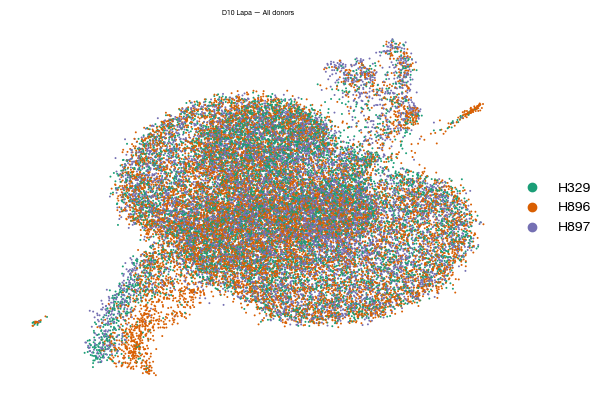

In [18]:
sc.pl.umap(
    adata, color=DONOR_KEY, palette=donor_palette,
    title="D10 Lapa — All donors", frameon=False,
    save="_d10_all_donors.pdf",
    size = 8
)

##### Overall D10 — Per-donor cell types (scanpy)

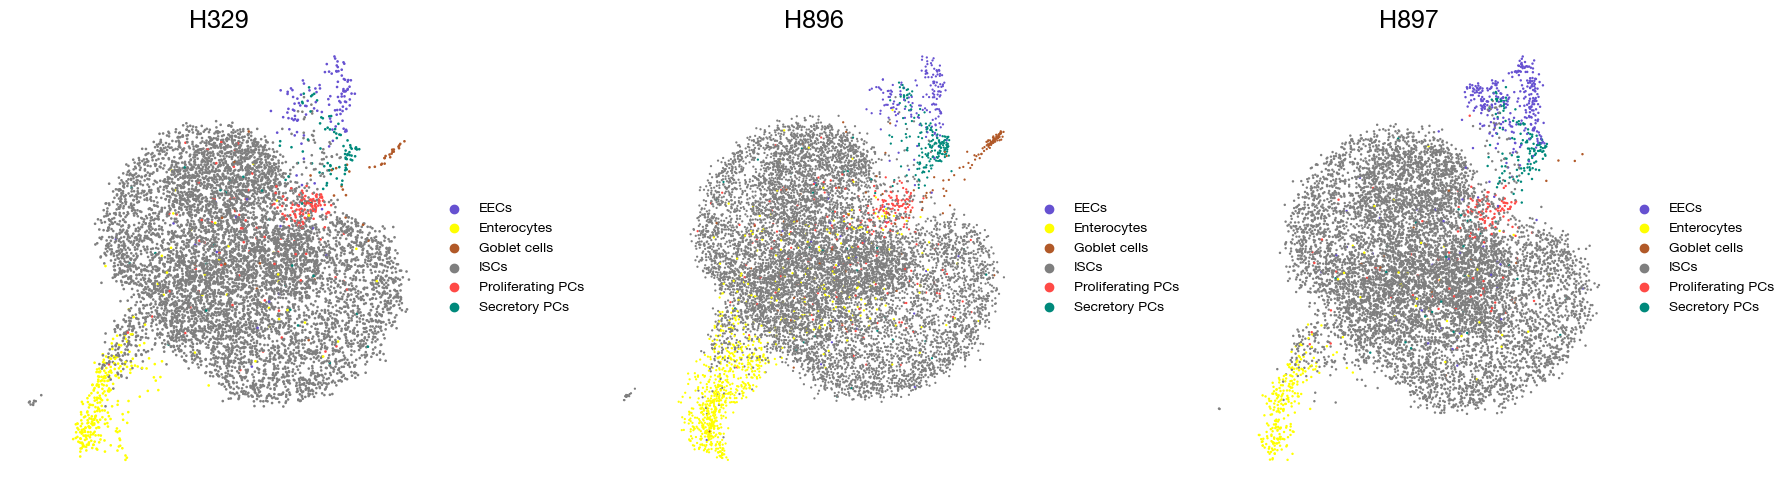

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, donor in zip(axes, REAL_DONORS):
    ad = adata[adata.obs[DONOR_KEY] == donor].copy()
    sc.pl.umap(
        ad, color=LABEL_KEY, palette=celltype_palette,
        title=donor,
        frameon=False, show=False, ax=ax,
    )
    ax.set_title(donor, fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "d10_per_donor_celltypes_scanpy_v2.pdf", dpi=DPI, bbox_inches="tight")
plt.show()

##### EEC subtypes — Per-donor (scanpy)

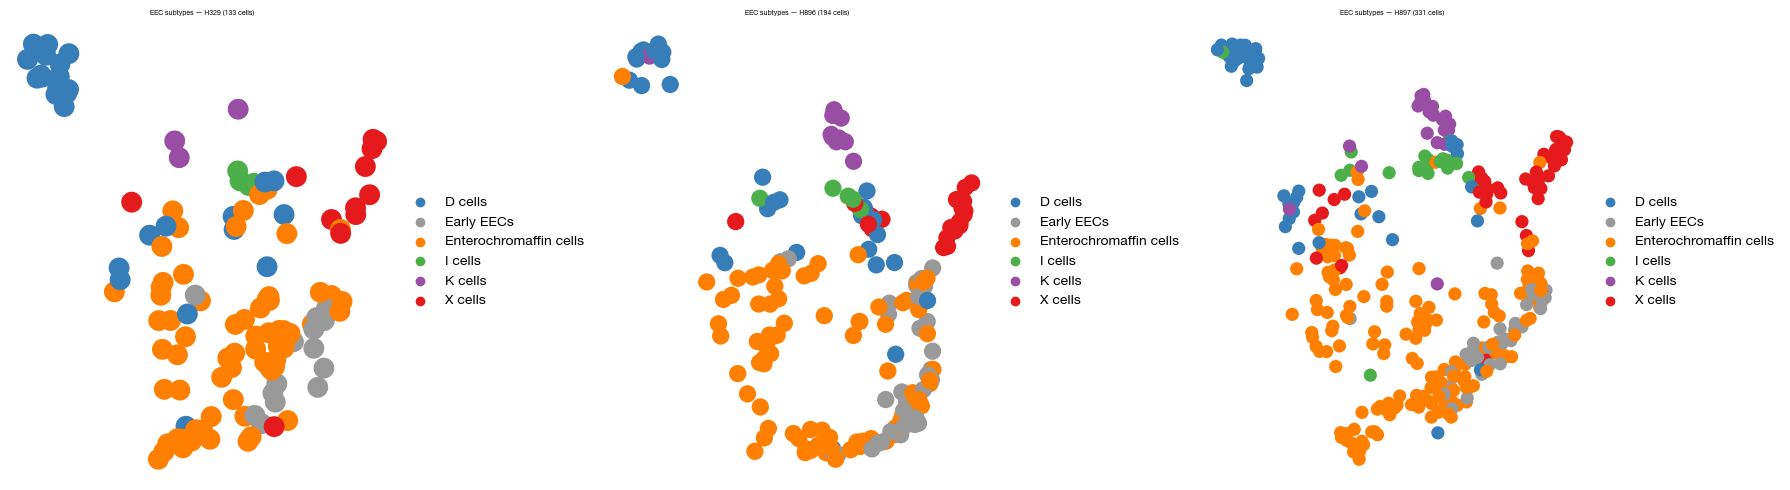

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, donor in zip(axes, REAL_DONORS):
    ad = adata_eec[adata_eec.obs[DONOR_KEY] == donor].copy()
    sc.pl.umap(
        ad, color=EEC_LABEL_KEY, palette=eec_palette,
        title=f"EEC subtypes — {donor} ({ad.n_obs:,} cells)",
        frameon=False, show=False, ax=ax,
    )
plt.tight_layout()
plt.savefig(SAVE_DIR / "eec_per_donor_subtypes_scanpy.pdf", dpi=DPI, bbox_inches="tight")
plt.show()

##### EEC subtypes — Per-donor (Veres)

Donor H329: 133 EECs


/Users/standale/user_generated/Work/breault-lab/single-cell/EGFRi-organoid-single-cell/src/vis.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


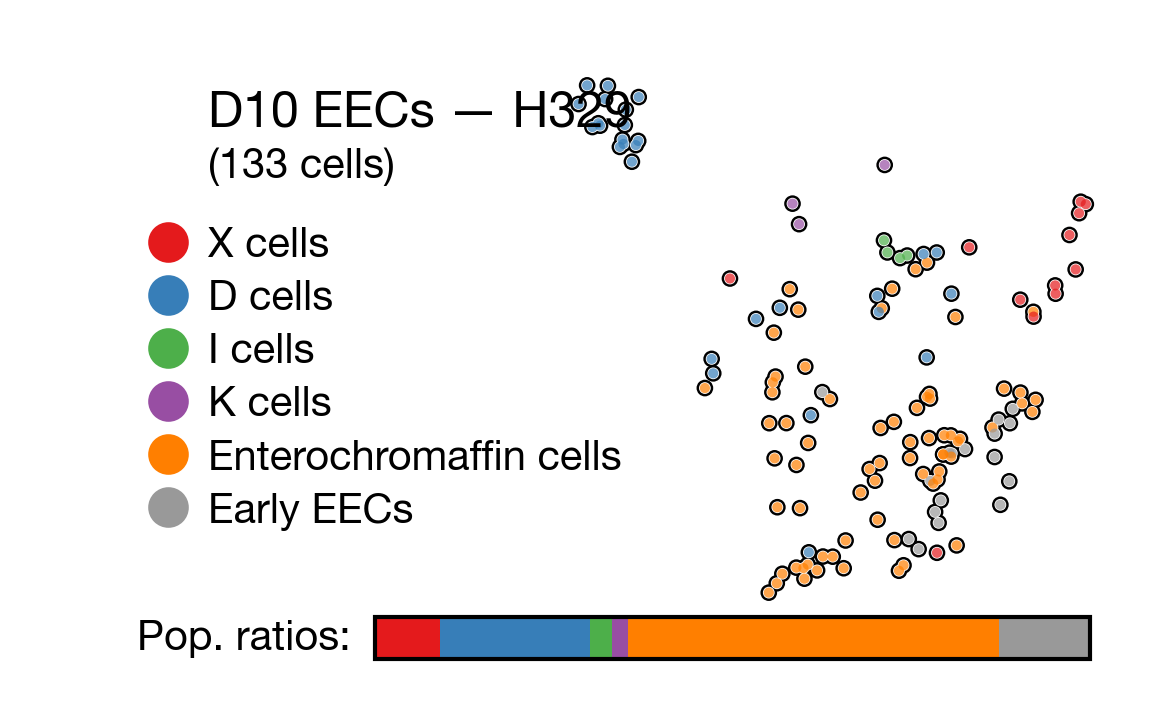

Donor H896: 194 EECs


/Users/standale/user_generated/Work/breault-lab/single-cell/EGFRi-organoid-single-cell/src/vis.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


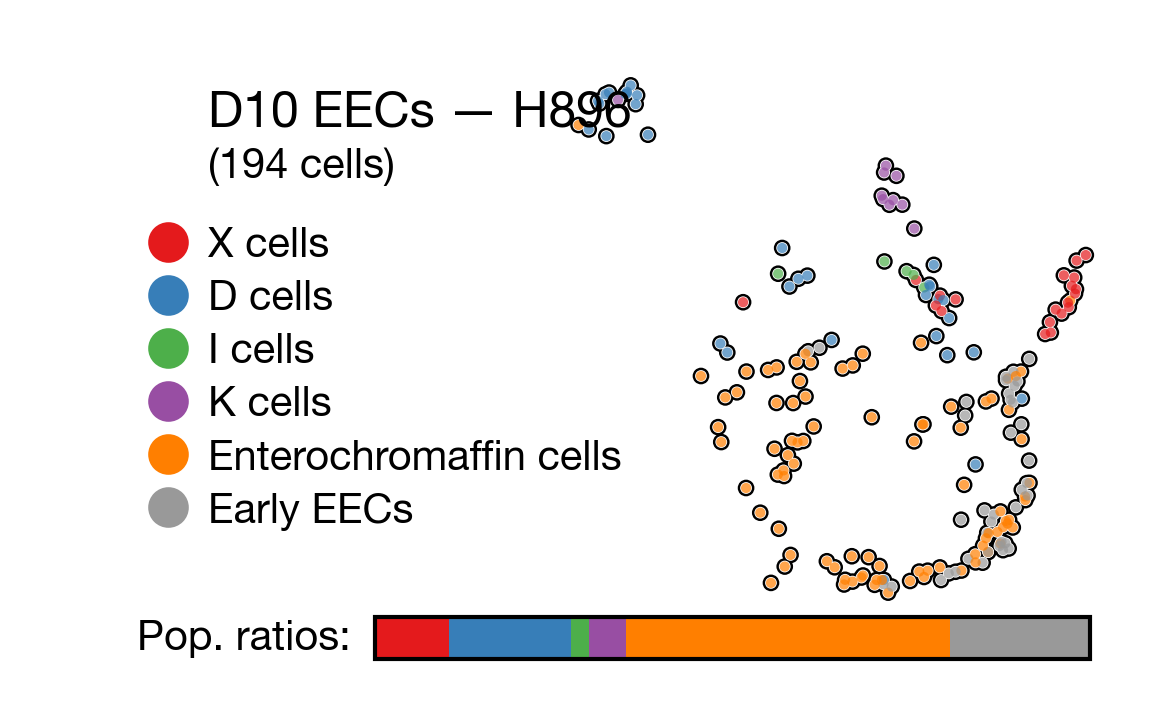

Donor H897: 331 EECs


/Users/standale/user_generated/Work/breault-lab/single-cell/EGFRi-organoid-single-cell/src/vis.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


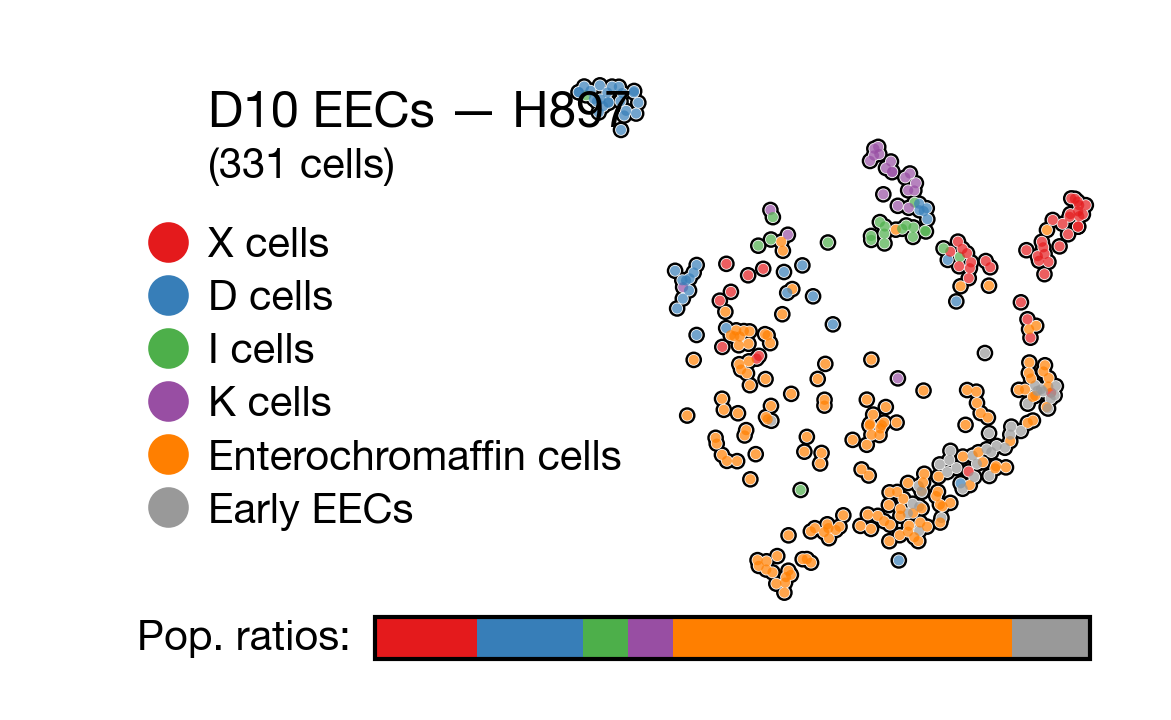

In [14]:
for donor in REAL_DONORS:
    ad = adata_eec[adata_eec.obs[DONOR_KEY] == donor].copy()
    print(f"Donor {donor}: {ad.n_obs:,} EECs")

    fig = plot_veres_panel(
        ad,
        label_key=EEC_LABEL_KEY,
        stage_text=f"D10 EECs — {donor}",
        label_order=EEC_LABEL_ORDER,
        ratio_order=EEC_LABEL_ORDER,
        palette=eec_palette,
        save=SAVE_DIR / f"eec_subtypes_{donor}_veres.pdf",
        dpi=DPI,
    )
    plt.show()
    plt.close(fig)

##### EEC subtypes — Per-donor (Veres triptych)

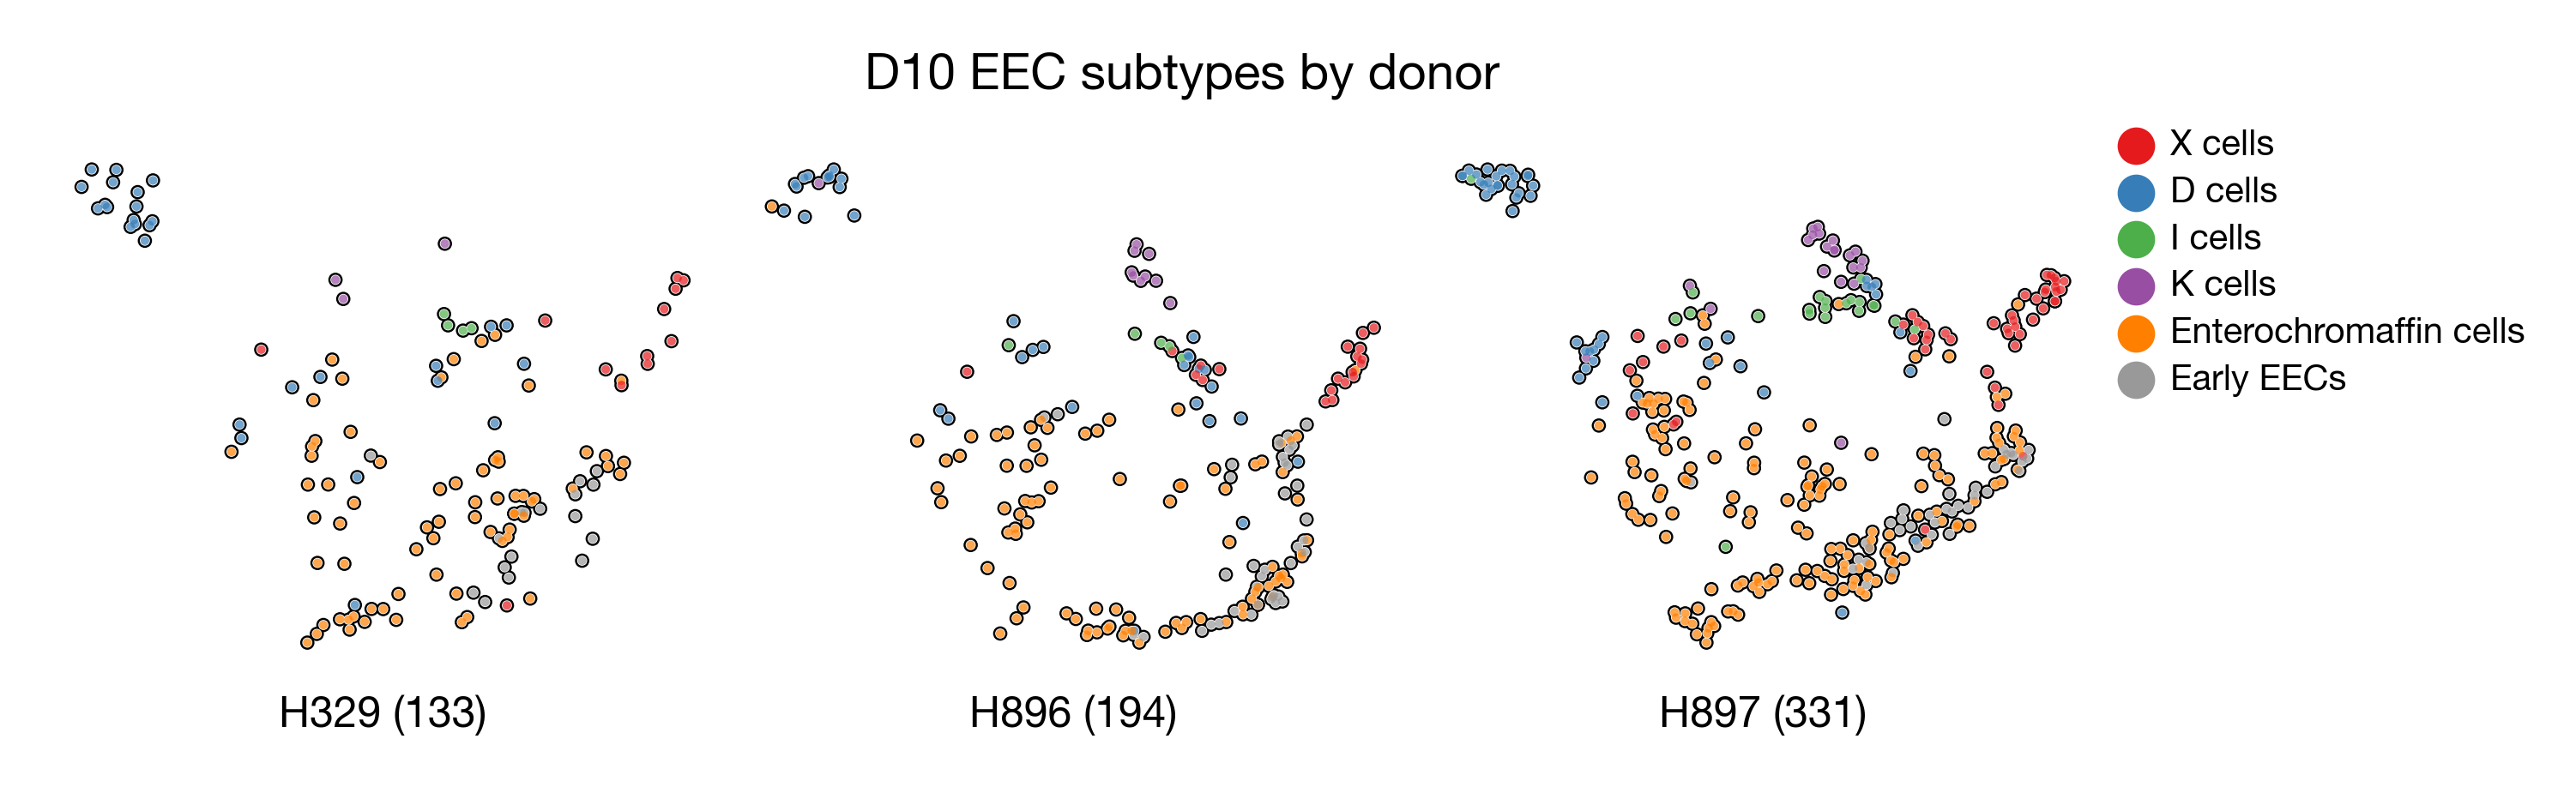

In [15]:
fig = plot_veres_triptych(
    adata_eec, split_key=DONOR_KEY, donors=REAL_DONORS,
    label_key=EEC_LABEL_KEY, label_order=EEC_LABEL_ORDER,
    palette=eec_palette, title="D10 EEC subtypes by donor",
    save=SAVE_DIR / "eec_per_donor_subtypes_triptych.pdf", dpi=DPI,
)
plt.show()
plt.close(fig)